# Harmonogramowanie metodą ścieżki krytycznej dla wprowadzenia produktu ubezpieczenia komunikacyjnego

## Podsumowanie zarządcze

Wprowadzenie na rynek indywidualnego ubezpieczenia komunikacyjnego to program międzyfunkcyjny: aktuariusze wyceniają ryzyko, dział zgodności składa taryfy do organu stanowego i czeka na zatwierdzenie, IT konfiguruje system administracji polisami, a dystrybucja szkoli agentów. Zadania te mają twarde relacje następstwa, więc datę wprowadzenia wyznacza najdłuższy łańcuch zależnych zadań w planie -- **ścieżka krytyczna**.

Ten notatnik buduje sieć projektu w reprezentacji Activity-on-Node złożoną z jedenastu zadań wprowadzenia i wyznacza pełny harmonogram **metodą ścieżki krytycznej (CPM)** za pomocą **PROC OPTMODEL**. Przejścia w przód i w tył w CPM to programy liniowe na grafie następstw: przejście w przód (najdłuższa ścieżka od początku) daje najwcześniejszy start i koniec każdego zadania, a przejście w tył (najdłuższa ścieżka) daje najpóźniejszy start i koniec oraz **całkowity zapas czasu** (luz harmonogramu). Wyniki poniżej są w całości generowane przez kod tego notatnika -- każda liczba w narracji jest odczytana z wykonanego wyniku.

**Co pokazuje harmonogram.** W pięciodniowym kalendarzu roboczym zakotwiczonym na 01JUN2026 program obejmuje **97 dni roboczych** i kończy się **13OCT2026**. Dziewięć z jedenastu zadań leży na ścieżce krytycznej (Start -> Badanie rynku -> Zebranie danych szkodowych -> Wycena -> Projekt systemu -> Budowa systemu -> UAT -> Szkolenie agentów -> Uruchomienie) i ma zerowy zapas. Tylko gałąź regulacyjna -- **złożenie taryf** i **zatwierdzenie** -- ma luz: każde może opóźnić się o maksymalnie **30 dni roboczych** bez przesunięcia wprowadzenia, ponieważ równoległa gałąź budowy systemu jest dłuższą z dwóch zbiegających się ścieżek.

## Jak to zbudowano

CPM to klasycznie procedura SAS/OR, ale jej rdzeniem obliczeniowym jest para problemów najdłuższej ścieżki na grafie następstw, które PROC OPTMODEL wyraża bezpośrednio jako niewielkie programy liniowe:

- **Przejście w przód (najwcześniejsze czasy).** Minimalizuj zmienne najwcześniejszego startu przy ograniczeniu `ES[successor] >= ES[predecessor] + duration + lag` dla każdego łuku następstwa. W optimum każde `ES` równa się najdłuższej ścieżce od początku projektu, tj. najwcześniejszemu możliwemu rozpoczęciu zadania.
- **Przejście w tył (najpóźniejsze czasy / zapas).** Wyznacz dla każdego zadania najdłuższą pozostałą ścieżkę do końca projektu (`TAIL`). Najpóźniejszy start wynosi wtedy `makespan - TAIL`, a **całkowity zapas** to `late start - early start`. Zadania o zerowym zapasie są krytyczne.

Sieć, czasy trwania, opóźnienia następstw i zapotrzebowanie na zasoby dla poszczególnych zadań są generowane w kodzie; nie ma żadnych danych zewnętrznych. Daty kalendarzowe w dniach roboczych wyznacza się za pomocą `INTNX('weekday', ...)`, dzięki czemu weekendy są pomijane.

## Dane

| Zbiór danych | Wiersze | Zmienne kluczowe | Opis |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Rejestr zadań: każde zadanie wprowadzenia, jego czas trwania w dniach roboczych oraz dzienna obsada aktuariuszy / deweloperów, jakiej wymaga |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Łuki następstwa sieci Activity-on-Node; `lag` to opóźnienie typu koniec-start w dniach roboczych (regulacyjny okres oczekiwania po zatwierdzeniu) |

Numeryczne identyfikatory zadań stanowią klucz sieci, dzięki czemu graf następstw czytelnie trafia do zbioru krotek OPTMODEL; czytelne nazwy `activity` są dołączane z powrotem do harmonogramu w dalszym kroku.

In [1]:
DANE acts;
   DŁUGOŚĆ activity $24;
   WEJŚCIE id activity $ dur actuary developer;
   DATALINES;
1 Start 3 1 0
2 BadanieRynku 8 2 0
3 DaneSzkód 10 3 0
4 Wycena 9 3 1
5 ZłożenieTaryf 4 1 0
6 Zatwierdzenie 6 1 0
7 ProjektSystemu 12 1 2
8 BudowaSystemu 18 0 3
9 UAT 15 0 2
10 SzkolenieAgentów 20 1 1
11 Uruchomienie 2 1 1
;
WYKONAJ;

DANE arcs;
   WEJŚCIE pred succ lag;
   DATALINES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
WYKONAJ;

/* widok wyłącznie numeryczny (czasy trwania) dla OPTMODEL */
DANE acts_n; USTAW acts; ZACHOWAJ id dur; WYKONAJ;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Przejście w przód -- najwcześniejszy start i koniec

Przejście w przód to program liniowy najdłuższej ścieżki. Ograniczenie `ES[j] >= ES[i] + dur[i] + lag[i,j]` dla każdego łuku wymusza, by każde zadanie rozpoczęło się nie wcześniej niż zakończą się wszyscy jego poprzednicy (plus ewentualne opóźnienie regulacyjne); minimalizacja zmiennych najwcześniejszego startu sprowadza każde do jego najdłuższej ścieżki poprzedników. Rozwiązane wartości `ES` zapisujemy bezpośrednio ze zmiennej OPTMODEL do `fwd`.

In [2]:
PROCEDURA optmodel;
   USTAW NODES; num dur{NODES};
   READ DANE acts_n INTO NODES=[id] dur=dur;

   USTAW <num,num> ARCS; num lag{ARCS};
   READ DANE arcs INTO ARCS=[pred succ] lag=lag;

   ZMIENNA ES{NODES} >= 0;
   con prec{<i,j> IN ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k IN NODES} ES[k];
   solve;

   CREATE DANE fwd FROM [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Przejście w tył -- najpóźniejsze czasy i całkowity zapas

`TAIL[a]` to najdłuższa ścieżka od zadania `a` do końca projektu, musi więc pokryć własny czas trwania zadania oraz, dla każdego następnika, opóźnienie plus ogon tego następnika: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Minimalizacja ogonów daje najciaśniejsze takie wartości. **Makespan** projektu to największy najwcześniejszy koniec; **najpóźniejszy start** każdego zadania to `makespan - TAIL`, a **całkowity zapas** to `late start - early start`. Zapas równy zeru wyznacza ścieżkę krytyczną.

In [3]:
PROCEDURA optmodel;
   USTAW NODES; num dur{NODES};
   READ DANE acts_n INTO NODES=[id] dur=dur;

   USTAW <num,num> ARCS; num lag{ARCS};
   READ DANE arcs INTO ARCS=[pred succ] lag=lag;

   ZMIENNA TAIL{NODES} >= 0;
   con BASE{a IN NODES}: TAIL[a] >= dur[a];
   con back{<i,j> IN ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k IN NODES} TAIL[k];
   solve;

   CREATE DANE bwd FROM [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Złożenie harmonogramu i kalendarza

Dołączamy najwcześniejsze starty i ogony z powrotem do rejestru zadań, wyznaczamy najpóźniejszy start / koniec oraz całkowity zapas, a przesunięcia w dniach roboczych mapujemy na daty kalendarzowe za pomocą `INTNX('weekday', ...)`, tak aby daty przypadały na dni robocze. Zadanie jest oznaczane jako **krytyczne**, gdy jego całkowity zapas wynosi zero.

In [4]:
%LET anchor = '01jun2026'd;

DANE sched0;
   POŁĄCZ acts fwd bwd; WEDŁUG id;
   ef = es + dur;            /* najwcześniejszy koniec */
WYKONAJ;

PROCEDURA ŚREDNIE DANE=sched0 NOPRINT;
   WYJŚCIE out=mk(USUŃ=_type_ _freq_) MAX(ef)=makespan;
WYKONAJ;

DANE sched;
   JEŚLI _n_=1 WTEDY USTAW mk;
   USTAW sched0;
   PRZECHOWAJ mspan;
   JEŚLI _n_=1 WTEDY mspan = makespan;
   ls = mspan - tail;        /* najpóźniejszy start  */
   lf = ls + dur;            /* najpóźniejszy koniec */
   tfloat = ls - es;         /* całkowity zapas */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   DŁUGOŚĆ cclass $12;
   JEŚLI critical WTEDY cclass='Krytyczna';
   PRZECIWNIE cclass='Rezerwa';
   format e_start e_finish l_start l_finish date9.;
WYKONAJ;

PROCEDURA SORTUJ DANE=sched out=sched_es; WEDŁUG es id; WYKONAJ;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## Harmonogram CPM

Najwcześniejszy/najpóźniejszy start i koniec podano w dniach roboczych od zakotwiczenia 01JUN2026 (dzień 0). Zadania klasy **Krytyczna** mają zerowy całkowity zapas.

In [5]:
TYTUŁ 'Harmonogram CPM -- czasy w dniach roboczych i całkowity zapas';
PROCEDURA DRUKUJ DANE=sched_es noobs ETYKIETA;
   ZMIENNA activity dur es ef ls lf tfloat cclass;
   ETYKIETA activity='Zadanie' dur='Czas (dni)' es='NS' ef='NK'
         ls='PS' lf='PK' tfloat='Całkowity zapas' cclass='Klasa';
WYKONAJ;

                             Harmonogram CPM -- czasy w dniach roboczych i całkowity zapas                              


          Zadanie  Czas (dni)  NS  NK  PS  PK   Całkowity zapas      Klasa
-----------------  ----------  --  --  --  --  ----------------  ---------
Start                       3   0   3   0   3                 0  Krytyczna
BadanieRynku                8   3  11   3  11                 0  Krytyczna
DaneSzkód                  10  11  21  11  21                 0  Krytyczna
Wycena                      9  21  30  21  30                 0  Krytyczna
ZłożenieTaryf               4  30  34  60  64                30  Rezerwa
ProjektSystemu             12  30  42  30  42                 0  Krytyczna
Zatwierdzenie               6  34  40  64  70                30  Rezerwa
BudowaSystemu              18  42  60  42  60                 0  Krytyczna
UAT                        15  60  75  60  75                 0  Krytyczna
SzkolenieAgentów           20  75  95  75  95           


NOTE: Option TITLE changed to Harmonogram CPM -- czasy w dniach roboczych i całkowity zapas.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


Kolumna najwcześniejszego startu odwzorowuje łańcuch zależności: Zadanie Start zaczyna się w dniu 0, a każde kolejne zadanie startuje, gdy zakończą się jego poprzednicy. Projekt kończy się w największym najwcześniejszym końcu.

## Ścieżka krytyczna

Wypisanie tylko zadań o zerowym zapasie, wraz z ich datami kalendarzowymi, daje łańcuch wyznaczający datę wprowadzenia. Każde opóźnienie tych zadań przesuwa wprowadzenie dzień w dzień.

In [6]:
TYTUŁ 'Ścieżka krytyczna (całkowity zapas = 0) z datami kalendarzowymi';
PROCEDURA DRUKUJ DANE=sched_es noobs ETYKIETA;
   GDZIE critical=1;
   ZMIENNA activity dur e_start e_finish;
   ETYKIETA activity='Zadanie' dur='Czas (dni)'
         e_start='Najwcześniejszy start' e_finish='Najwcześniejszy koniec';
WYKONAJ;

DANE mkrep;
   USTAW mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   format anchor FINISH date9.;
WYKONAJ;
TYTUŁ 'Czas trwania projektu';
PROCEDURA DRUKUJ DANE=mkrep noobs ETYKIETA;
   ZMIENNA anchor makespan FINISH;
   ETYKIETA anchor='Zakotwiczenie (dzień 0)'
         makespan='Makespan (dni robocze)'
         FINISH='Prognozowany koniec';
WYKONAJ;

                            Ścieżka krytyczna (całkowity zapas = 0) z datami kalendarzowymi                             


          Zadanie  Czas (dni)   Najwcześniejszy start   Najwcześniejszy koniec
-----------------  ----------  ----------------------  -----------------------
Start                       3               01JUN2026                03JUN2026
BadanieRynku                8               04JUN2026                15JUN2026
DaneSzkód                  10               16JUN2026                29JUN2026
Wycena                      9               30JUN2026                10JUL2026
ProjektSystemu             12               13JUL2026                28JUL2026
BudowaSystemu              18               29JUL2026                21AUG2026
UAT                        15               24AUG2026                11SEP2026
SzkolenieAgentów           20               14SEP2026                09OCT2026
Uruchomienie                2               12OCT2026                13OCT2026

       


NOTE: Option TITLE changed to Ścieżka krytyczna (całkowity zapas = 0) z datami kalendarzowymi.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Czas trwania projektu.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Gdzie jest luz

Zadania niekrytyczne to gałąź regulacyjna. Ich najpóźniejszy start / koniec pokazują, jak daleko każde może się przesunąć, zanim zacznie przesuwać wprowadzenie. Wolny zapas jest tu równy całkowitemu zapasowi, ponieważ żadne inne zadanie nie zależy od nich aż do ponownego złączenia przy szkoleniu agentów.

In [7]:
TYTUŁ 'Zadania niekrytyczne i ich zapas harmonogramu';
PROCEDURA DRUKUJ DANE=sched_es noobs ETYKIETA;
   GDZIE critical=0;
   ZMIENNA activity dur e_start e_finish l_start l_finish tfloat;
   ETYKIETA activity='Zadanie' dur='Czas (dni)'
         e_start='Najwcześniejszy start' e_finish='Najwcześniejszy koniec'
         l_start='Najpóźniejszy start' l_finish='Najpóźniejszy koniec'
         tfloat='Całkowity zapas';
WYKONAJ;

                                     Zadania niekrytyczne i ich zapas harmonogramu                                      


        Zadanie  Czas (dni)   Najwcześniejszy start   Najwcześniejszy koniec    Najpóźniejszy start    Najpóźniejszy koniec   Całkowity zapas
---------------  ----------  ----------------------  -----------------------  ---------------------  ----------------------  ----------------
ZłożenieTaryf             4               13JUL2026                16JUL2026              24AUG2026               27AUG2026                30
Zatwierdzenie             6               17JUL2026                24JUL2026              28AUG2026               04SEP2026                30




NOTE: Option TITLE changed to Zadania niekrytyczne i ich zapas harmonogramu.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Wodospad harmonogramu

Słupek typu high-low dla każdego zadania, rysowany od jego najwcześniejszego startu do najwcześniejszego końca w kolejności projektu, daje wodospad planu w stylu Gantta. Wysokość każdego słupka to czas trwania zadania, a schody wspinają się do makespanu wynoszącego 97 dni roboczych. Zadania leżące *poniżej* wznoszącej się przekątnej -- tam, gdzie szczyt słupka jest niżej niż dół kolejnego słupka -- to te z luzem.

                        Wprowadzenie produktu komunikacyjnego -- wodospad wczesnego harmonogramu                        




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Wprowadzenie produktu komunikacyjnego -- wodospad wczesnego harmonogramu.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


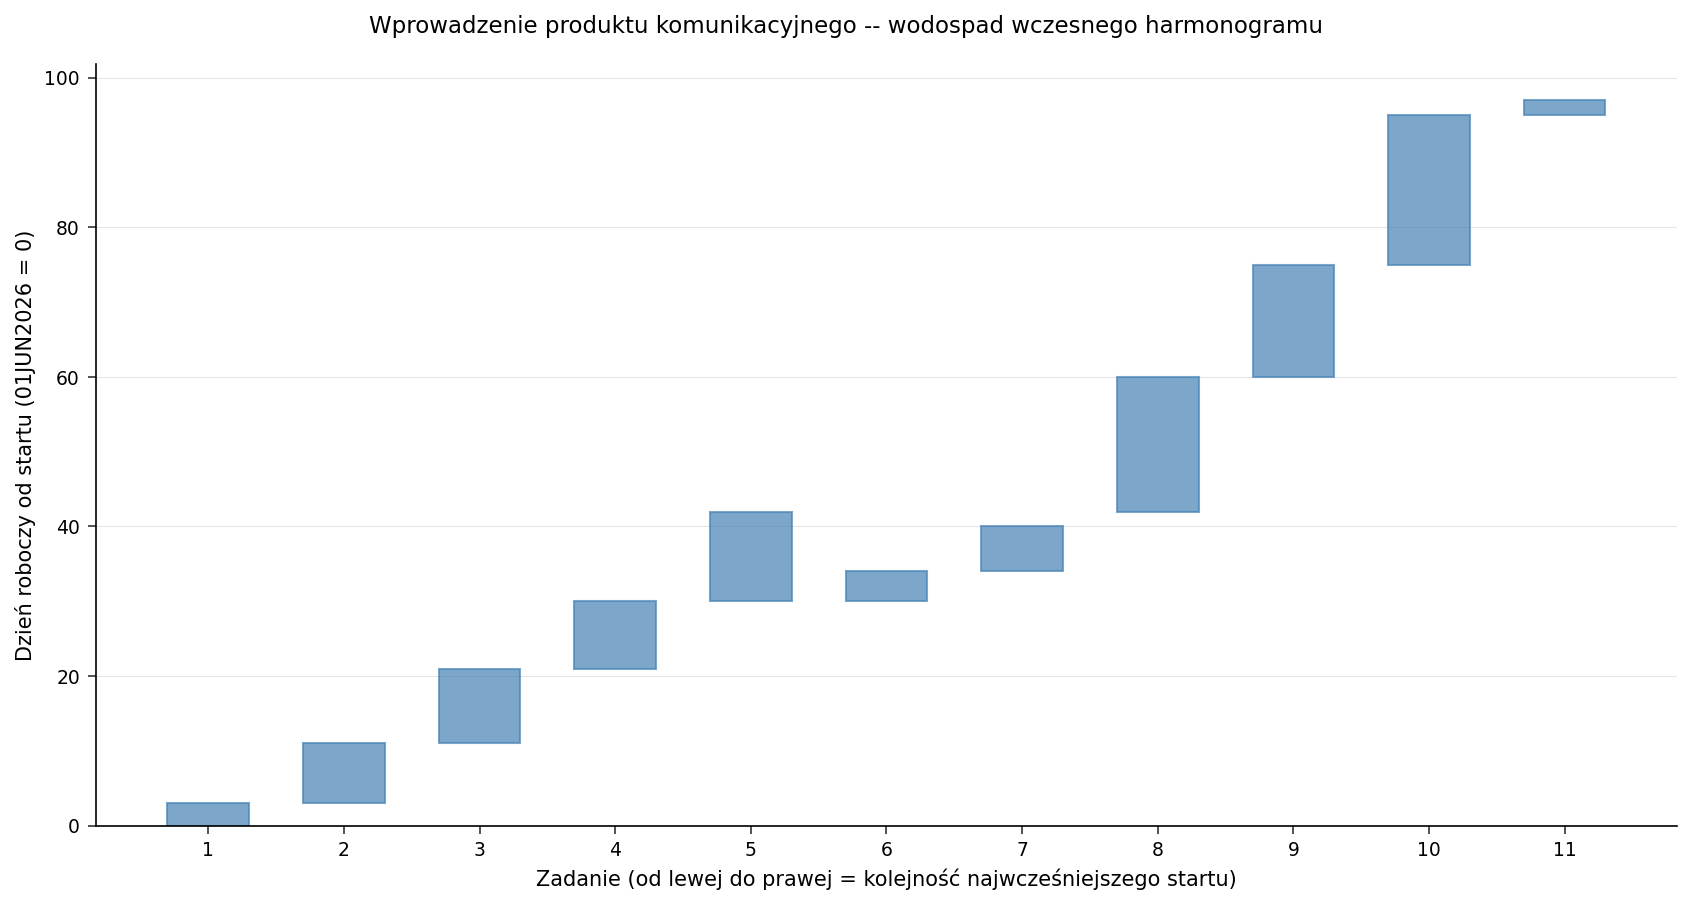

In [8]:
DANE gantt; USTAW sched_es;
   ord = es;          /* numeryczne x = kolejność najwcześniejszego startu */
WYKONAJ;
PROCEDURA SORTUJ DANE=gantt; WEDŁUG ord activity; WYKONAJ;
DANE gantt; USTAW gantt; ax = _n_; WYKONAJ;   /* zwarty indeks x 1..11 */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
TYTUŁ 'Wprowadzenie produktu komunikacyjnego -- wodospad wczesnego harmonogramu';
PROCEDURA SGPLOT DANE=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS ETYKIETA='Zadanie (od lewej do prawej = kolejność najwcześniejszego startu)'
         integer VALUES=(1 TO 11 WEDŁUG 1);
   YAXIS ETYKIETA='Dzień roboczy od startu (01JUN2026 = 0)' grid;
WYKONAJ;
ODS GRAPHICS OFF;

Czytając od lewej do prawej, słupki wznoszą się nieprzerwanie wzdłuż łańcucha krytycznego. Dwa zadania, których słupki przerywają schody -- zaczynając niżej niż szczyt poprzedniego słupka -- to złożenie taryf i zatwierdzenie, czyli czynności niosące zapas.

## Całkowity zapas według zadania

Wykreślenie całkowitego zapasu każdego zadania sprawia, że ścieżka krytyczna staje się jednoznaczna: każde zadanie krytyczne leży na zerze, a tylko dwa zadania regulacyjne wznoszą się ponad nie.

                               Całkowity zapas według zadania (0 = na ścieżce krytycznej)                               




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Całkowity zapas według zadania (0 = na ścieżce krytycznej).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


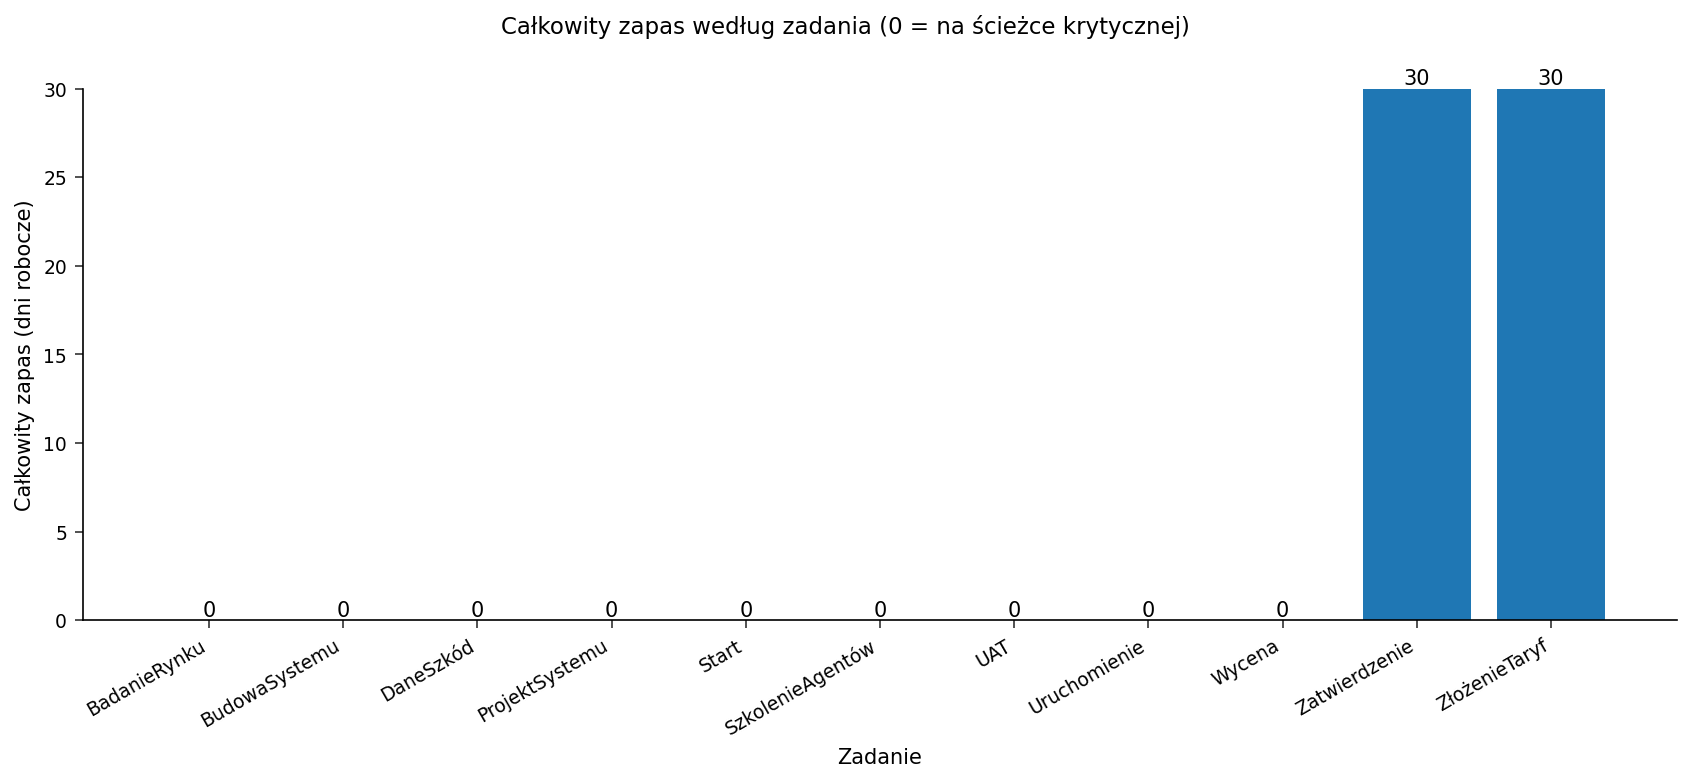

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
TYTUŁ 'Całkowity zapas według zadania (0 = na ścieżce krytycznej)';
PROCEDURA SGPLOT DANE=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS ETYKIETA='Zadanie' fitpolicy=rotatethin;
   YAXIS ETYKIETA='Całkowity zapas (dni robocze)';
WYKONAJ;
ODS GRAPHICS OFF;

## Obciążenie zasobów przy wczesnym harmonogramie

Poza terminami plan rywalizuje o dwie pule specjalistów. Rozwinięcie każdego zadania na dni robocze, które zajmuje, i zsumowanie dziennego zapotrzebowania daje profil obciążenia zasobów -- ilu aktuariuszy i deweloperów plan potrzebuje każdego dnia, jeśli każde zadanie rozpoczyna się możliwie najwcześniej. Szczyt to największa moc, jakiej program kiedykolwiek wymaga jednocześnie.

                               Szczytowe dzienne obciążenie zasobów (wczesny harmonogram)                               

                                                  The MEANS Procedure

 Variable    Label           Maximum
 -----------------------------------
 ACTUARIES   Aktuariusze           3
 DEVELOPERS  Deweloperzy           3
 -----------------------------------

                        Dzienne obciążenie aktuariuszy i deweloperów przy wczesnym harmonogramie                        




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Szczytowe dzienne obciążenie zasobów (wczesny harmonogram).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Dzienne obciążenie aktuariuszy i deweloperów przy wczesnym harmonogramie.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


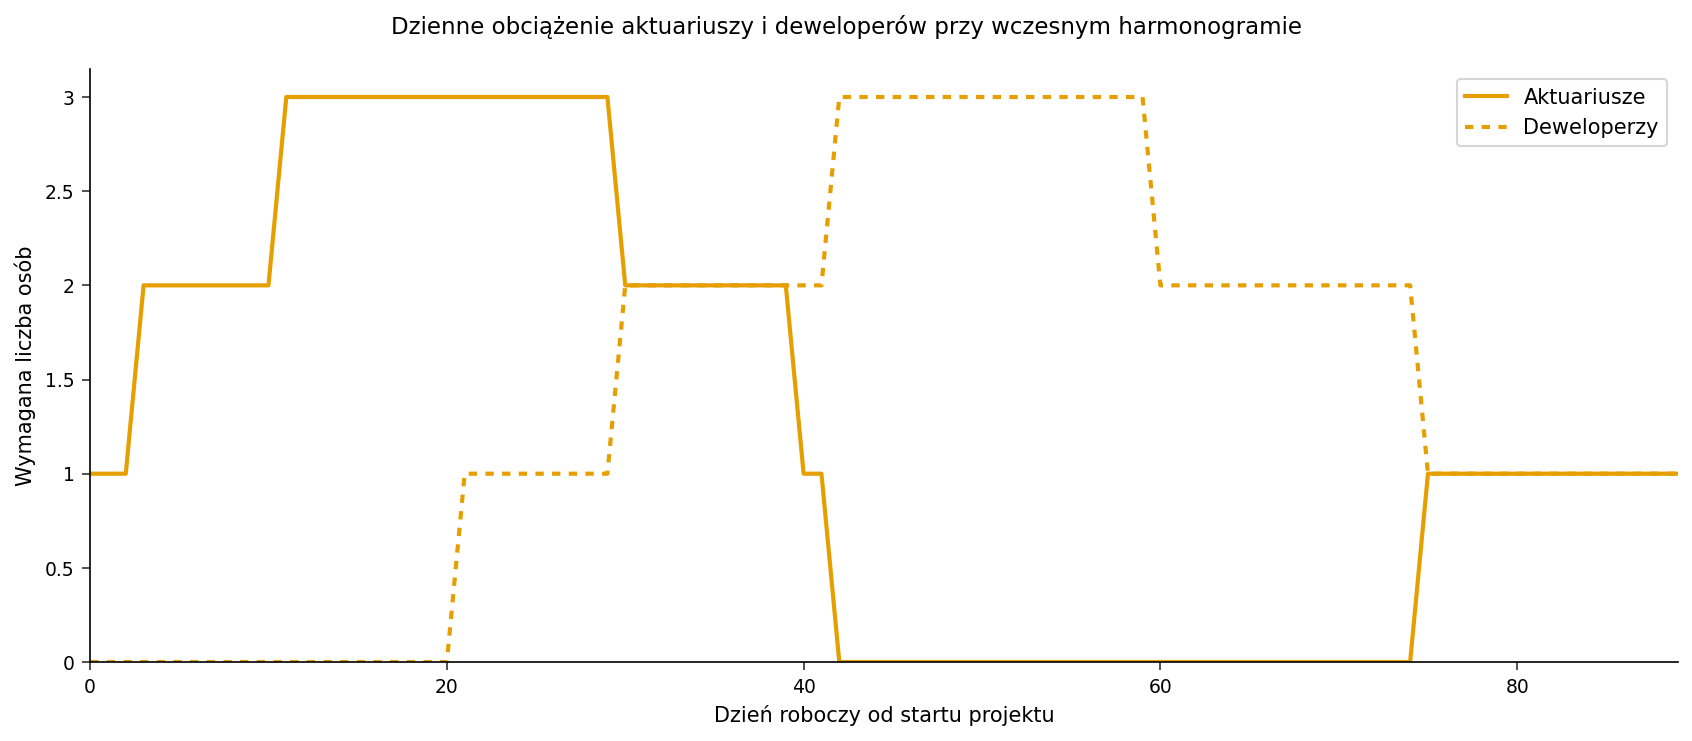

In [10]:
DANE LOAD;
   USTAW sched;
   POWTÓRZ d = es TO ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      WYJŚCIE;
   KONIEC;
   ZACHOWAJ day a_use d_use;
WYKONAJ;

PROCEDURA ŚREDNIE DANE=LOAD NOPRINT NWAY;
   KLASA day;
   ZMIENNA a_use d_use;
   WYJŚCIE out=rprofile(USUŃ=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
WYKONAJ;
PROCEDURA SORTUJ DANE=rprofile; WEDŁUG day; WYKONAJ;

TYTUŁ 'Szczytowe dzienne obciążenie zasobów (wczesny harmonogram)';
PROCEDURA ŚREDNIE DANE=rprofile MAX maxdec=0;
   ZMIENNA actuaries developers;
   ETYKIETA actuaries='Aktuariusze' developers='Deweloperzy';
WYKONAJ;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
TYTUŁ 'Dzienne obciążenie aktuariuszy i deweloperów przy wczesnym harmonogramie';
PROCEDURA SGPLOT DANE=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='Aktuariusze';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='Deweloperzy';
   XAXIS ETYKIETA='Dzień roboczy od startu projektu';
   YAXIS ETYKIETA='Wymagana liczba osób' MIN=0;
   keylegend / location=inside position=topright;
WYKONAJ;
ODS GRAPHICS OFF;

## Interpretacja wyników

- **Datę wprowadzenia wyznacza tor budowy, a nie tor regulacyjny.** Ścieżka krytyczna biegnie Start -> Badanie rynku -> Zebranie danych szkodowych -> Wycena -> Projekt systemu -> Budowa systemu -> UAT -> Szkolenie agentów -> Uruchomienie, dając makespan 97 dni roboczych (koniec 13OCT2026). Każde z tych zadań ma zerowy zapas, więc każde opóźnienie przesuwa wprowadzenie dzień w dzień.

- **Gałąź regulacyjna ma miesiąc luzu.** Złożenie taryf i zatwierdzenie niosą po 30 dni roboczych całkowitego zapasu. Po zakończeniu wyceny mogą wystartować tak późno, jak ich najpóźniejsze daty startu, i wciąż zdążyć na czas do szkolenia agentów, ponieważ równoległa gałąź budowy systemu (projekt systemu -> budowa systemu -> UAT) jest dłuższą z dwóch ścieżek zasilających wprowadzenie. W kategoriach planowania to nie złożenie taryf jest tu ograniczeniem wiążącym -- jest nim budowa systemu polisowego.

- **Zapotrzebowanie na specjalistów osiąga szczyt w różnych fazach.** Profil obciążenia pokazuje, że zapotrzebowanie na aktuariuszy szczytuje wcześnie (do wyceny), a na deweloperów później (do budowy systemu), każde osiągając maksimum trzech osób dziennie. Ponieważ oba szczyty przypadają na różne fazy, mały, sekwencyjny zespół specjalistów jest w stanie obsadzić plan -- program nie potrzebuje jednocześnie maksymalnej obsady aktuariuszy i deweloperów.

**Wniosek biznesowy.** CPM zamienia listę zadań wprowadzenia w wykonalny harmonogram: wskazuje czynności toru budowy, które ubezpieczyciel musi chronić, aby osiągnąć 13OCT2026, kwantyfikuje miesiąc luzu dostępny na złożeniu regulacyjnym oraz pokazuje, że rozsunięte szczyty zapotrzebowania na aktuariuszy i deweloperów pozwalają szczupłemu zespołowi specjalistów zrealizować plan.

*Uwaga implementacyjna:* SAS liczy to za pomocą PROC CPM (SAS/OR). Jenner osiąga ten sam wynik ścieżki krytycznej w przód/w tył za pomocą PROC OPTMODEL, rozwiązując dwa programy liniowe najdłuższej ścieżki leżące u podstaw tej metody.